In [ ]:
#importing modules
from datasets import load_dataset

ds = load_dataset("akashsalmuthe/passportDataset")
print(ds)

passportData.arrow: reconstructing file:   0%|          |  0.00B /  298MB            

passportData.arrow: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['caption', 'image'],
        num_rows: 600
    })
})


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Checking the dataset

print(ds["train"])
print(ds["train"].features)

Dataset({
    features: ['caption', 'image'],
    num_rows: 600
})
{'caption': Value('string'), 'image': Image(mode=None, decode=True)}


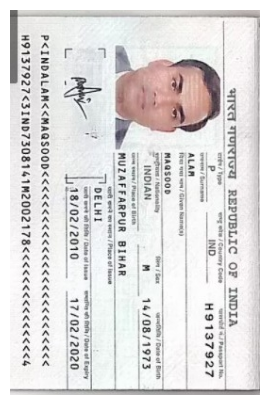

Caption: 'The image displays an Indian passport with the following details: Type "P" for Personal, Country Code "IND" for India, Passport No. "H9137927". The surname of the passport holder is Alam and the given name is Maqsood. The nationality is listed as Indian. The gender (Sex) of the holder is "M" for male. The date of birth is presented as 14/08/1973. The place of birth is Muzaffarpur, Bihar. The issuing authority is in Delhi, with the passport issued on 18/02/2010 and an expiry date of 17/02/2020.'


In [ ]:
# Displaying one passport image

sample = ds["train"][0]

plt.figure(figsize=(8, 5))
plt.imshow(sample["image"])
plt.axis("off")
plt.show()

print("Caption:", sample["caption"])

In [ ]:
for i in range(10):
    print(i, ds["train"][i]["caption"])

0 'The image displays an Indian passport with the following details: Type "P" for Personal, Country Code "IND" for India, Passport No. "H9137927". The surname of the passport holder is Alam and the given name is Maqsood. The nationality is listed as Indian. The gender (Sex) of the holder is "M" for male. The date of birth is presented as 14/08/1973. The place of birth is Muzaffarpur, Bihar. The issuing authority is in Delhi, with the passport issued on 18/02/2010 and an expiry date of 17/02/2020.'
1 "The image provided is of an Indian passport with the following details: The type of passport is 'P' for a personal passport. The country code 'IND' signifies India. The passport number is J2452409. The surname of the passport holder is Kaushal, and the given name is Sukhdeep. The nationality is Indian. The holder's sex is female, indicated by 'F'. The date of birth is 20/10/1991. The place of birth is Gailb Kalan. The passport was issued in Chandigarh on 31/08/2010, with an expiration date

In [ ]:
# Preparing passport images

IMG_SIZE = (128, 128)

passport_images = []

for item in ds["train"]:
    image = item["image"].convert("RGB")
    image = image.resize(IMG_SIZE)
    passport_images.append(np.array(image))

passport_images = np.array(passport_images)

print("Passport images:", passport_images.shape)

Passport images: (600, 128, 128, 3)


In [ ]:
# Show all variables currently created

%whos

Variable                Type               Data/Info
----------------------------------------------------
IMG_SIZE                tuple              n=2
classification_report   function           <function classification_<...>report at 0x7e8b9ffe4180>
confusion_matrix        function           <function confusion_matrix at 0x7e8b9ff0af20>
ds                      DatasetDict        DatasetDict({\n    train:<...>num_rows: 600\n    })\n})
i                       int                9
image                   Image              <PIL.Image.Image image mo<...>28x128 at 0x7E8C724DDDB0>
item                    dict               n=2
keras                   KerasLazyLoader    <KerasLazyLoader>
layers                  module             <module 'keras._tf_keras.<...>eras/layers/__init__.py'>
load_dataset            function           <function load_dataset at 0x7e8c5632f060>
non_passport_images     list               n=0
np                      module             <module 'numpy' from '/us<...>kage

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving non passport (1).zip to non passport (1).zip


In [ ]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print(os.listdir('/content'))

['.config', '.ipynb_checkpoints', 'non passport (1).zip', 'non passport', 'sample_data']


In [ ]:
# Loading non-passport images

import os
from PIL import Image
import numpy as np

IMG_SIZE = (128, 128)

non_passport_images = []

folder_path = "/content/non passport"

for filename in os.listdir(folder_path):

    file_path = os.path.join(folder_path, filename)

    try:
        image = Image.open(file_path).convert("RGB")
        image = image.resize(IMG_SIZE)

        non_passport_images.append(np.array(image))

    except:
        # Ignore files that are not images
        pass

non_passport_images = np.array(non_passport_images)

print("Non-passport images:", non_passport_images.shape)

Non-passport images: (333, 128, 128, 3)


In [ ]:
print("Passport images:", passport_images.shape)
print("Non-passport images:", non_passport_images.shape)

Passport images: (600, 128, 128, 3)
Non-passport images: (333, 128, 128, 3)


In [ ]:
# Creating labels

passport_labels = np.ones(len(passport_images))
non_passport_labels = np.zeros(len(non_passport_images))

print("Passport labels:", len(passport_labels))
print("Non-passport labels:", len(non_passport_labels))

Passport labels: 600
Non-passport labels: 333


In [ ]:
# Combining images

X = np.concatenate(
    [passport_images, non_passport_images],
    axis=0
)

y = np.concatenate(
    [passport_labels, non_passport_labels],
    axis=0
)

print("Total images:", X.shape)
print("Total labels:", y.shape)

Total images: (933, 128, 128, 3)
Total labels: (933,)


In [ ]:
# Normalizing pixel values

X = X.astype("float32") / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
# Splitting into training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (746, 128, 128, 3)
Testing images: (187, 128, 128, 3)


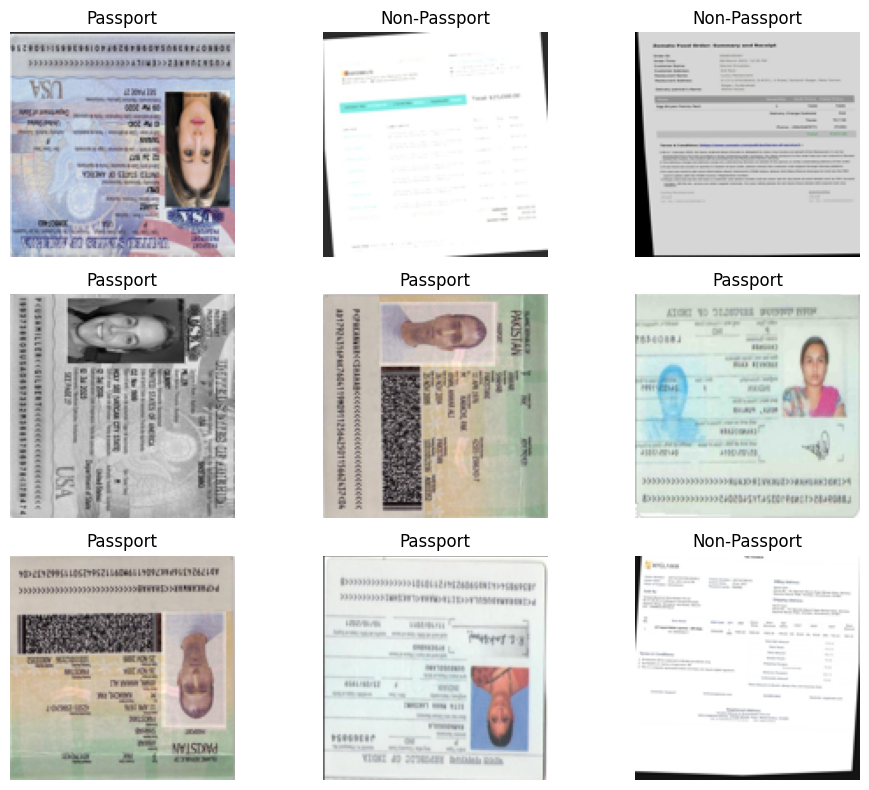

In [ ]:
# Displaying sample images

class_names = ["Non-Passport", "Passport"]

plt.figure(figsize=(10, 8))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(X_train[i])

    label = int(y_train[i])

    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Creating CNN model

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([

    # First convolution layer
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(128, 128, 3)
    ),

    # Pooling
    layers.MaxPooling2D((2, 2)),

    # Second convolution layer
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    # Third convolution layer
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    # Flatten feature maps
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Output: Passport / Non-Passport
    layers.Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compiling the model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Training the CNN

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6275 - loss: 0.7106 - val_accuracy: 0.6867 - val_loss: 0.6025
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7584 - loss: 0.4631 - val_accuracy: 0.8067 - val_loss: 0.3430
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9144 - loss: 0.2456 - val_accuracy: 0.8400 - val_loss: 0.3480
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9480 - loss: 0.1479 - val_accuracy: 0.9600 - val_loss: 0.1299
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9648 - loss: 0.0955 - val_accuracy: 0.9733 - val_loss: 0.1105
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9832 - loss: 0.0569 - val_accuracy: 0.9800 - val_loss: 0.1025
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9916 - loss: 0.0271 - val_accuracy: 0.9733 - val_loss: 0.0723
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9866 - loss: 0.0426 - val_accuracy: 0.9867 - val_loss:

In [ ]:
# Evaluating the model

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 0.9840 - loss: 0.1031
Test Accuracy: 0.9839572310447693


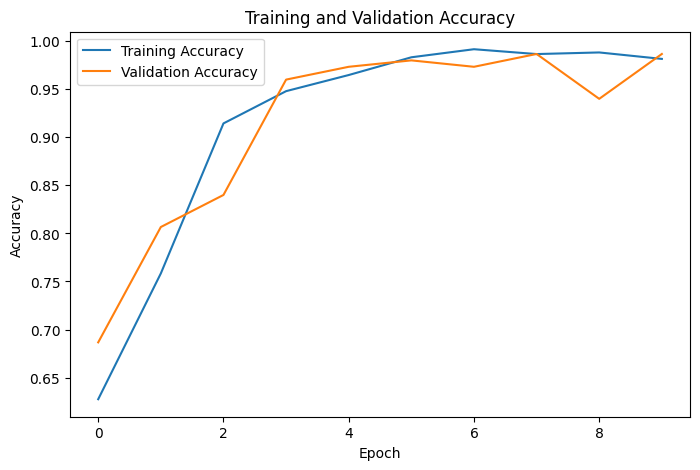

In [ ]:
# Plotting accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

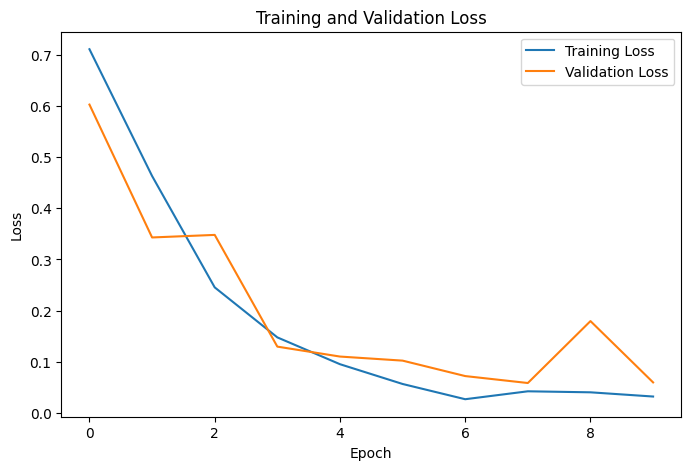

In [ ]:
# Plotting loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [ ]:
# Making predictions

predictions = model.predict(X_test)

y_pred = (predictions >= 0.5).astype(int).flatten()

print("Predictions completed.")

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 258ms/step
Predictions completed.


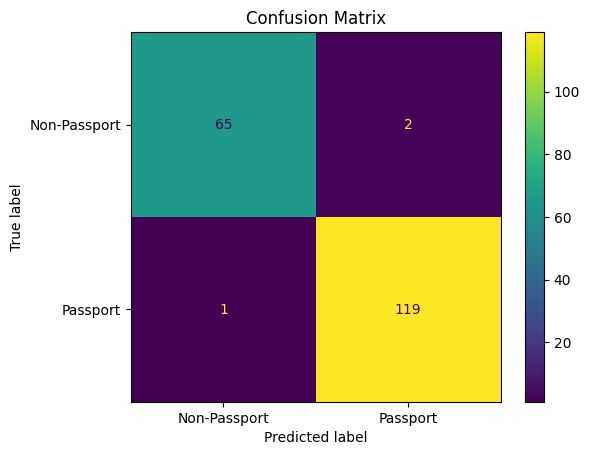

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Passport", "Passport"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Passport", "Passport"]
    )
)

              precision    recall  f1-score   support

Non-Passport       0.98      0.97      0.98        67
    Passport       0.98      0.99      0.99       120

    accuracy                           0.98       187
   macro avg       0.98      0.98      0.98       187
weighted avg       0.98      0.98      0.98       187



In [ ]:
# Upload an image for testing

from google.colab import files

uploaded = files.upload()

Saving 55.jpg to 55.jpg


In [ ]:
# Predicting uploaded image

filename = list(uploaded.keys())[0]

image = Image.open(filename).convert("RGB")
image = image.resize(IMG_SIZE)

image_array = np.array(image).astype("float32") / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = float(
    model.predict(image_array, verbose=0)[0][0]
)

if prediction >= 0.5:
    result = "PASSPORT"
    confidence = prediction
else:
    result = "NON-PASSPORT"
    confidence = 1 - prediction

print("Prediction:", result)
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: NON-PASSPORT
Confidence: 100.0 %


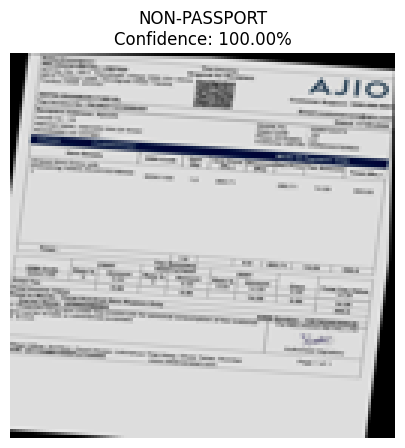

In [ ]:
# Displaying the result

plt.figure(figsize=(8, 5))

plt.imshow(image)

plt.title(
    f"{result}\nConfidence: {confidence * 100:.2f}%"
)

plt.axis("off")
plt.show()